In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label

In [3]:
ds = xr.open_zarr('/data1/michsh/daily_thirstwave/BHIST_1231_007.zarr')
ds

<xarray.Dataset> Size: 797MB
Dimensions:          (AMOC: 1, member: 1, time: 35310, lat: 30, lon: 47)
Coordinates:
  * AMOC             (AMOC) object 8B '1231'
    dayofyear        (time) float64 282kB dask.array<chunksize=(17655,), meta=np.ndarray>
  * lat              (lat) float64 240B 24.03 24.97 25.92 ... 49.48 50.42 51.36
  * lon              (lon) float64 376B 235.0 236.2 237.5 ... 290.0 291.2 292.5
  * member           (member) object 8B '007'
    quantile         float64 8B ...
  * time             (time) object 282kB 1850-04-01 00:00:00 ... 2014-10-31 0...
Data variables:
    ET_os            (AMOC, member, time, lat, lon) float32 199MB dask.array<chunksize=(1, 1, 35310, 25, 25), meta=np.ndarray>
    actual_tw_ET_os  (AMOC, member, time, lat, lon) float32 199MB dask.array<chunksize=(1, 1, 35310, 25, 25), meta=np.ndarray>
    event_id         (AMOC, member, lat, lon, time) int32 199MB dask.array<chunksize=(1, 1, 25, 25, 35310), meta=np.ndarray>
    tw_intensity     (AMOC, member, time, lat, lon) float32 199MB dask.array<chunksize=(1, 1, 14, 25, 25), meta=np.ndarray>

# Combine 90th Percentile

In [ ]:
lat = 44.0
lon_ = -96.0
lon = lon_ if 360 <= 180 else (lon_ + 360)

<xarray.DataArray 'threshold90' (dayofyear: 214)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(214,), dtype=float64, chunksize=(15,), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 2kB 91 92 93 94 95 96 ... 300 301 302 303 304
    lat        float64 8B 43.82
    lon        float64 8B 263.8
    quantile   float64 8B 0.9


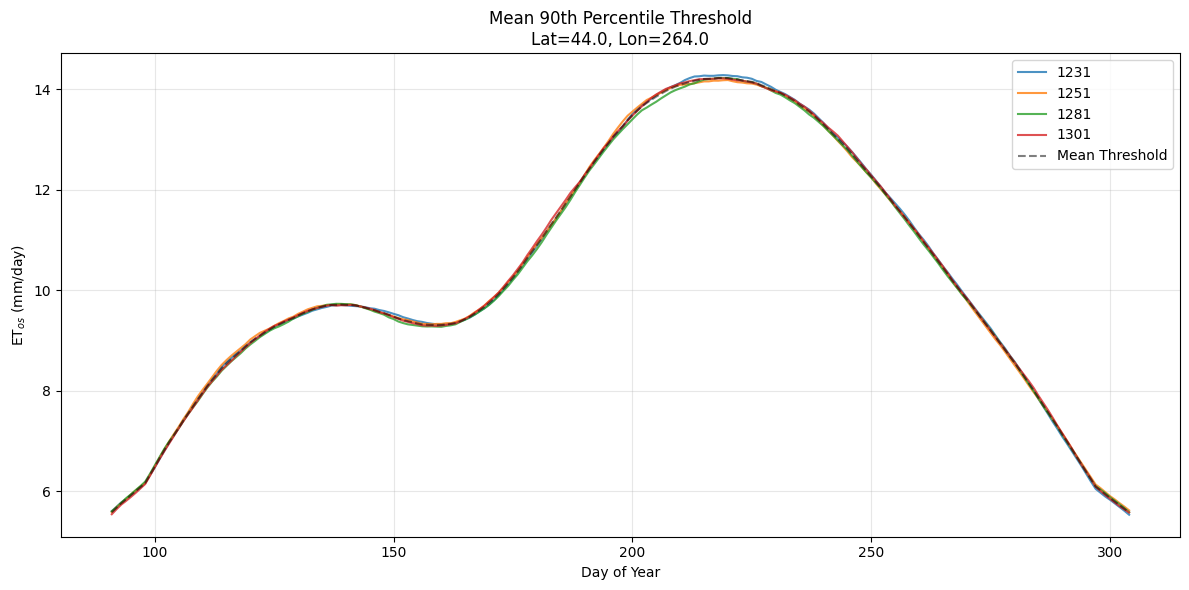

In [19]:
AMOC = ['1231', '1251', '1281', '1301']

# Store each AMOC threshold
threshold_list = []

for AMOC_state in AMOC:

    ds = xr.open_zarr(
        f"/data1/michsh/90th_zarr/HIST_{AMOC_state}_ensemble_threshold.zarr"
    )

    threshold = ds["threshold90"]

    # Select nearest grid point
    point = threshold.sel(
        lat=lat,
        lon=lon,
        method="nearest"
    )

    # Add AMOC coordinate
    point = point.expand_dims(AMOC=[AMOC_state])

    threshold_list.append(point)

# -------------------------------------------------
# Combine all AMOC states and compute daily mean
# -------------------------------------------------
all_thresholds = xr.concat(threshold_list, dim="AMOC")

mean_threshold = all_thresholds.mean(dim="AMOC")

print(mean_threshold)

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(12,6))

# Individual AMOC states
for state in AMOC:
    plt.plot(
        all_thresholds.sel(AMOC=state)["dayofyear"],
        all_thresholds.sel(AMOC=state),
        linewidth=1.5,
        alpha=0.8,
        label=f"{state}"
    )

# Mean
plt.plot(
    mean_threshold["dayofyear"],
    mean_threshold,
    color="black",
    ls='--',
    linewidth=1.5,
    alpha=0.5,
    label="Mean Threshold"
)

plt.xlabel("Day of Year")
plt.ylabel("ET$_{os}$ (mm/day)")
plt.title(f"Mean 90th Percentile Threshold\nLat={lat}, Lon={lon}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [20]:
import xarray as xr

AMOC = ['1231', '1251', '1281', '1301']

# Store each AMOC threshold dataset
threshold_list = []

for AMOC_state in AMOC:

    ds = xr.open_zarr(
        f"/data1/michsh/90th_zarr/HIST_{AMOC_state}_ensemble_threshold.zarr"
    )

    # Add AMOC dimension
    threshold = ds["threshold90"].expand_dims(AMOC=[AMOC_state])

    threshold_list.append(threshold)

# -------------------------------------------------
# Combine all AMOC states and compute mean
# -------------------------------------------------
all_thresholds = xr.concat(threshold_list, dim="AMOC")

mean_threshold = all_thresholds.mean(dim="AMOC")

# Convert back to Dataset
mean_ds = mean_threshold.to_dataset(name="threshold90")

# -------------------------------------------------
# Save to Zarr
# -------------------------------------------------
output_path = "/data1/michsh/90th_zarr/HIST_BASELINE.zarr"

mean_ds.to_zarr(output_path, mode="w")

print(f"Saved mean threshold dataset to:\n{output_path}")

Saved mean threshold dataset to:
/data1/michsh/90th_zarr/HIST_BASELINE.zarr


<xarray.Dataset> Size: 2MB
Dimensions:      (dayofyear: 214, lat: 30, lon: 47)
Coordinates:
  * dayofyear    (dayofyear) int64 2kB 91 92 93 94 95 96 ... 300 301 302 303 304
  * lat          (lat) float64 240B 24.03 24.97 25.92 ... 49.48 50.42 51.36
  * lon          (lon) float64 376B 235.0 236.2 237.5 ... 290.0 291.2 292.5
    quantile     float64 8B ...
Data variables:
    threshold90  (dayofyear, lat, lon) float64 2MB dask.array<chunksize=(15, 30, 47), meta=np.ndarray>


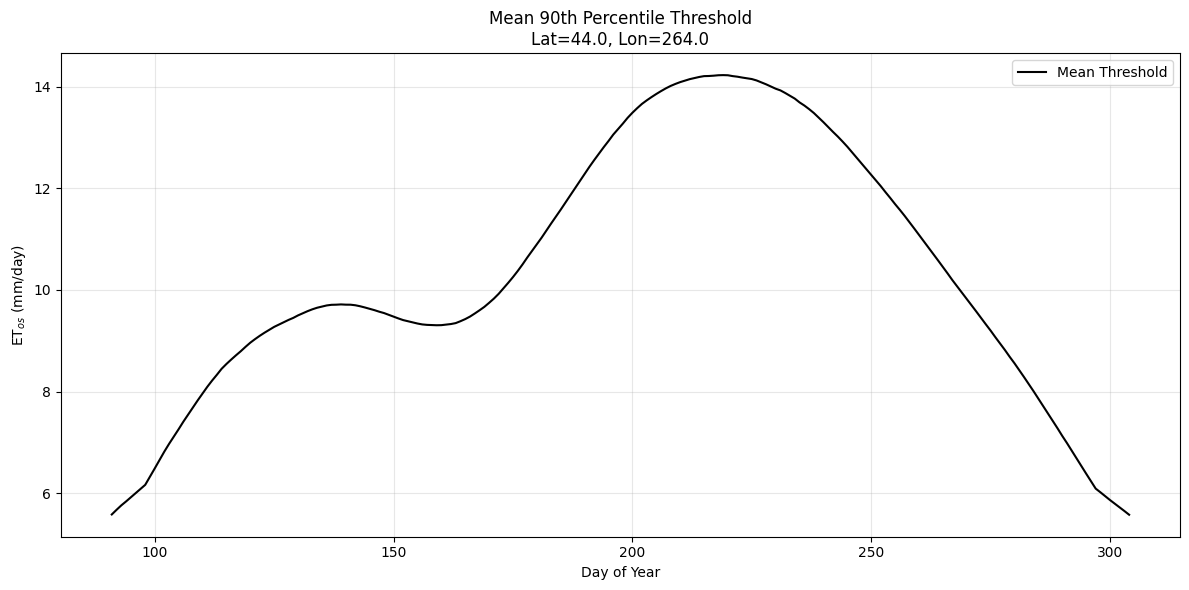

In [21]:
baseline = xr.open_zarr(
    "/data1/michsh/90th_zarr/HIST_BASELINE.zarr"
)

print(baseline)

mean_baseline = baseline['threshold90']

# Select nearest grid point
point = mean_baseline.sel(
    lat=lat,
    lon=lon,
    method="nearest"
)

plt.figure(figsize=(12,6))

plt.plot(
    point["dayofyear"],
    point,
    color="black",
    #ls="--",
    linewidth=1.5,
    label="Mean Threshold"
)

plt.xlabel("Day of Year")
plt.ylabel("ET$_{os}$ (mm/day)")
plt.title(f"Mean 90th Percentile Threshold\nLat={lat}, Lon={lon}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Combine Daily Thirstwave Metrics

In [ ]:
AMOC_state = ['1231', '1251', '1281', '1301']
members = [f"{i:03d}" for i in range(1, 21)]

# Store each AMOC_state threshold
threshold_list = []

for state in AMOC_state:
    for member in members:

        # Make sure the file naming convention is correct
        if time_period == 'BHIST':
            if int(member) <= 10:
                bmb = f'{time_period}cmip6'
            else:
                bmb = f'{time_period}smbb' 

        if time_period == 'BSSP370':
            if int(member) <= 10:
                bmb = f'{time_period}cmip6'
            else:
                bmb = f'{time_period}smbb' 

        file_name = f'{bmb}_LE2-{state}.{member}_ETos_daily.nc'

        file_path = Path(f'{input_data_path}/{state}/{member}/{file_name}')

        # Verify the file exists before trying to open it
        if file_path.exists():
            print(f"Opening: {file_name}")

        # Open the file
        ds = xr.open_dataset(file_path)

    else:
        print(f"Warning: File not found -> {file_name}")

        ds = xr.open_zarr(
            f"/data1/michsh/90th_zarr/HIST_{AMOC_state}_ensemble_threshold.zarr"
        )

        # Add AMOC dimension
        threshold = ds["threshold90"].expand_dims(AMOC=[AMOC_state])

        threshold_list.append(threshold)

# -------------------------------------------------
# Combine all AMOC states and compute mean
# -------------------------------------------------
all_thresholds = xr.concat(threshold_list, dim="AMOC")

mean_threshold = all_thresholds.mean(dim="AMOC")

# Convert back to Dataset
mean_ds = mean_threshold.to_dataset(name="threshold90")

# -------------------------------------------------
# Save to Zarr
# -------------------------------------------------
output_path = "/data1/michsh/90th_zarr/HIST_BASELINE.zarr"

mean_ds.to_zarr(output_path, mode="w")

print(f"Saved mean threshold dataset to:\n{output_path}")

# Plotting Caclulations

In [45]:
# Define lat and lon we want to investigate for thirstwaves

lat = 44.0
lon = -96.0

target_year = '2006'

# Adjust bounds 
if ds_CONUS['lon'].max() > 180 and lon < 0:
    actual_lon = lon + 360  
else:
    actual_lon = lon

print(actual_lon, lat) 

# Take the data from the nearist lat/lon
point = ds_CONUS.sel(
    lat=lat,
    lon=actual_lon,
    method="nearest"
)

print(point)

# For the 90th percentile spread plot, group by time.dayofyear
group = point.groupby("time.dayofyear")

daily_min = group.min()
daily_max = group.max()
daily_p90 = group.quantile(0.90)

daily_p90 = (
    daily_p90
    .rolling(
        dayofyear=15,
        center=True,
        min_periods=8
    )
    .mean()
)

# Now we want to determine the year that data should be plotted aginst
year = point.sel(time=target_year)

threshold_target_year = daily_p90.sel(
    dayofyear=year.time.dt.dayofyear
)

# Compare ET_os to threshold
above = (year > threshold_target_year).values

# Array that will mark thirstwave days
thirstwave = np.zeros_like(above, dtype=bool)

# Find consecutive runs
start = None

print(year.shape)
print(threshold_target_year.shape)
print((year > threshold_target_year).shape)

print(year.dims)
print(threshold_target_year.dims)

for i, val in enumerate(above):

    if val and start is None:
        start = i

    elif not val and start is not None:

        # Length of the run
        if i - start >= 3:
            thirstwave[start:i] = True

        start = None

# Handle case where the series ends during a thirstwave
if start is not None:
    if len(above) - start >= 3:
        thirstwave[start:] = True

264.0 44.0
<xarray.DataArray 'ET_os' (time: 35310)> Size: 141kB
array([2.01552 , 2.963275, 2.866343, ..., 5.322733, 2.60886 , 3.683225],
      dtype=float32)
Coordinates:
    lat      float64 8B 43.82
    lon      float64 8B 263.8
  * time     (time) object 282kB 1850-04-01 00:00:00 ... 2014-10-31 00:00:00
Attributes:
    units:      mm/day
    long_name:  Short Crop Refrence Evapotranspiration
(214,)
(214,)
(214,)
('time',)
('time',)


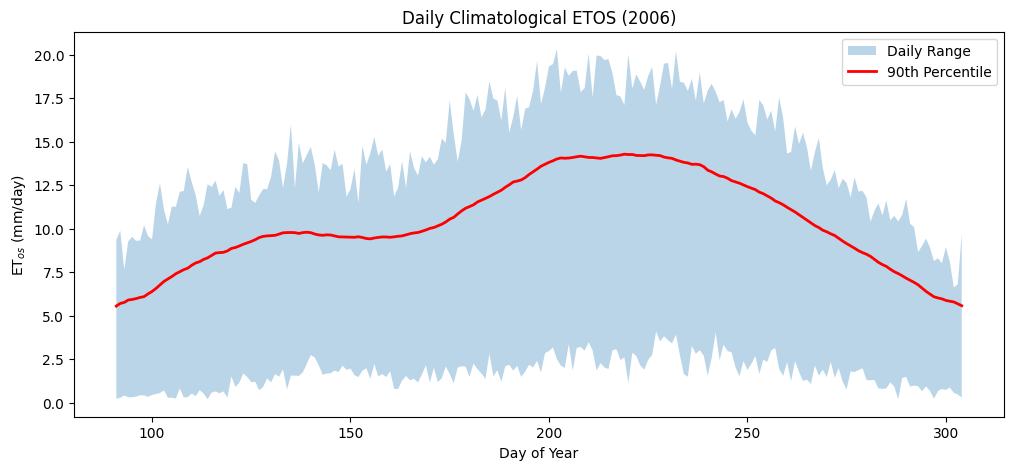

In [46]:
plt.figure(figsize=(12,5))

plt.fill_between(
    daily_min.dayofyear,
    daily_min,
    daily_max,
    alpha=0.3,
    label="Daily Range"
)

plt.plot(
    daily_p90.dayofyear,
    daily_p90,
    color="red",
    linewidth=2,
    label="90th Percentile"
)

plt.xlabel("Day of Year")
plt.ylabel("ET$_{os}$ (mm/day)")
plt.title(f"Daily Climatological ETOS ({target_year})")
plt.legend()

plt.show()


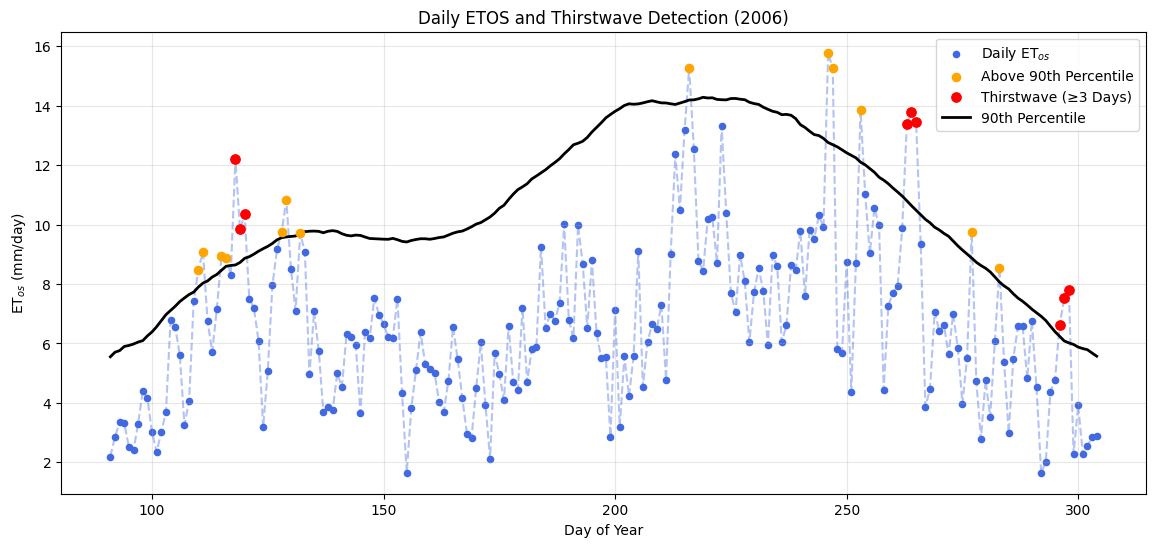

In [47]:
plt.figure(figsize=(14,6))

# Entire year
plt.plot(
    year.time.dt.dayofyear,
    year,
    '--',
    color='royalblue',
    alpha=0.4
)

plt.scatter(
    year.time.dt.dayofyear,
    year,
    s=20,
    color='royalblue',
    label='Daily ET$_{os}$'
)

# Days above the 90th percentile
plt.scatter(
    year.time.dt.dayofyear.values[above],
    year.values[above],
    s=35,
    color='orange',
    label='Above 90th Percentile',
    zorder=3
)

# Days that belong to thirstwaves
plt.scatter(
    year.time.dt.dayofyear.values[thirstwave],
    year.values[thirstwave],
    s=45,
    color='red',
    label='Thirstwave (≥3 Days)',
    zorder=4
)

# Threshold
plt.plot(
    daily_p90.dayofyear,
    daily_p90,
    color='black',
    linewidth=2,
    label='90th Percentile'
)

plt.xlabel("Day of Year")
plt.ylabel("ET$_{os}$ (mm/day)")
plt.title(f"Daily ETOS and Thirstwave Detection ({target_year})")
plt.grid(alpha=0.3)
plt.legend()

plt.show()